In [83]:
import numpy as np          
import pandas as pd                      
import matplotlib.pyplot as plt        
import seaborn as sns

In [84]:
df=pd.read_csv('C:/Users/sonal/Downloads/Bank+Customer+Churn/Bank_Churn.csv')

In [85]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# EDA

In [86]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [88]:
df.isnull().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

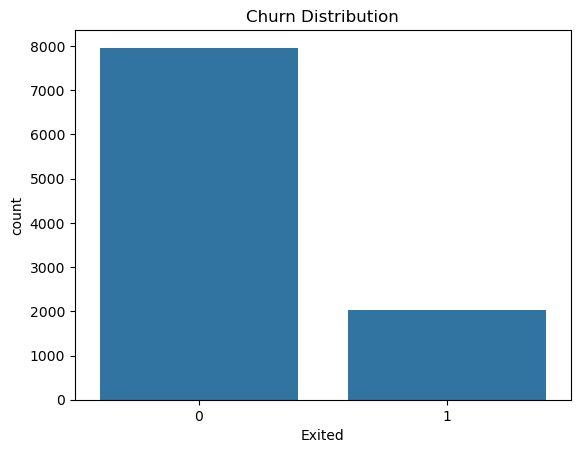

In [89]:
sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.show()

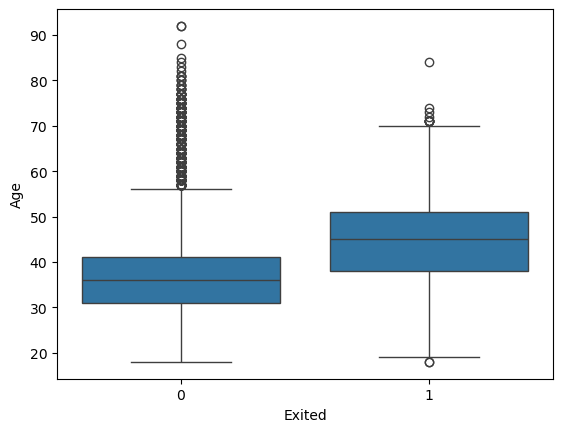

In [90]:
sns.boxplot(x='Exited', y='Age', data=df)
plt.show()

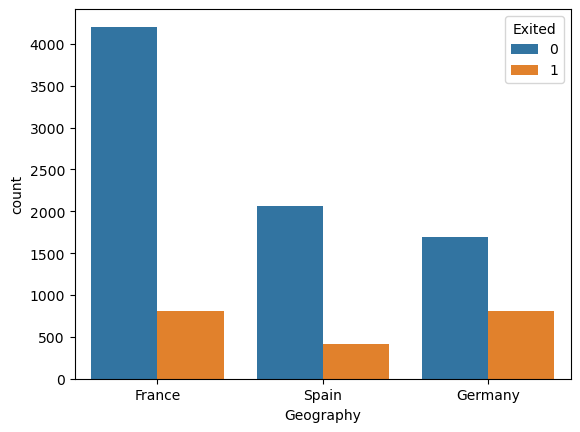

In [91]:
sns.countplot(x='Geography', hue='Exited', data=df)
plt.show()

<Axes: xlabel='Exited', ylabel='Balance'>

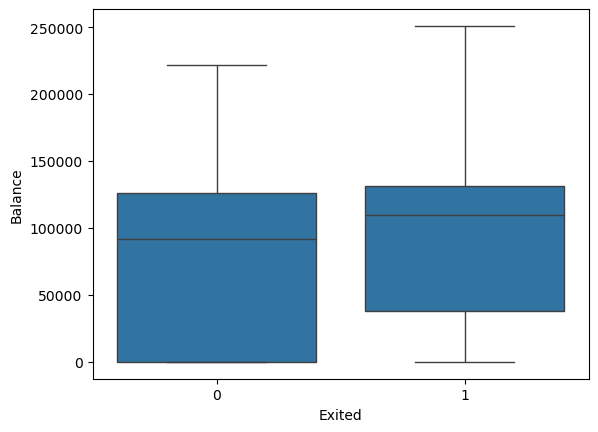

In [92]:
sns.boxplot(x='Exited', y='Balance', data=df)

<Axes: xlabel='Geography', ylabel='count'>

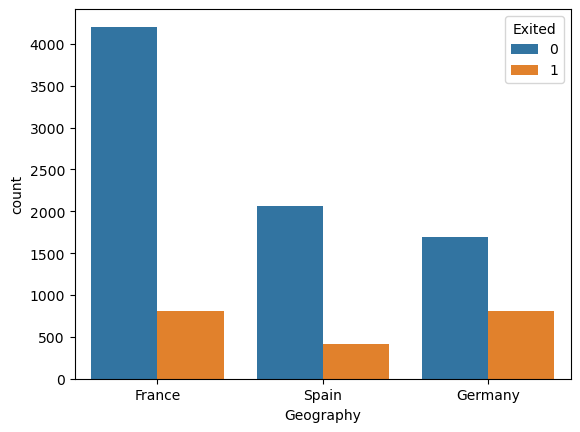

In [93]:
sns.countplot(x='Geography', hue='Exited', data=df)

<Axes: xlabel='IsActiveMember', ylabel='count'>

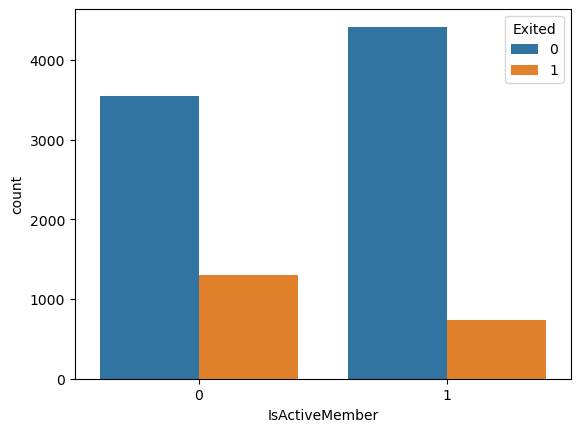

In [94]:
sns.countplot(x='IsActiveMember', hue='Exited', data=df)

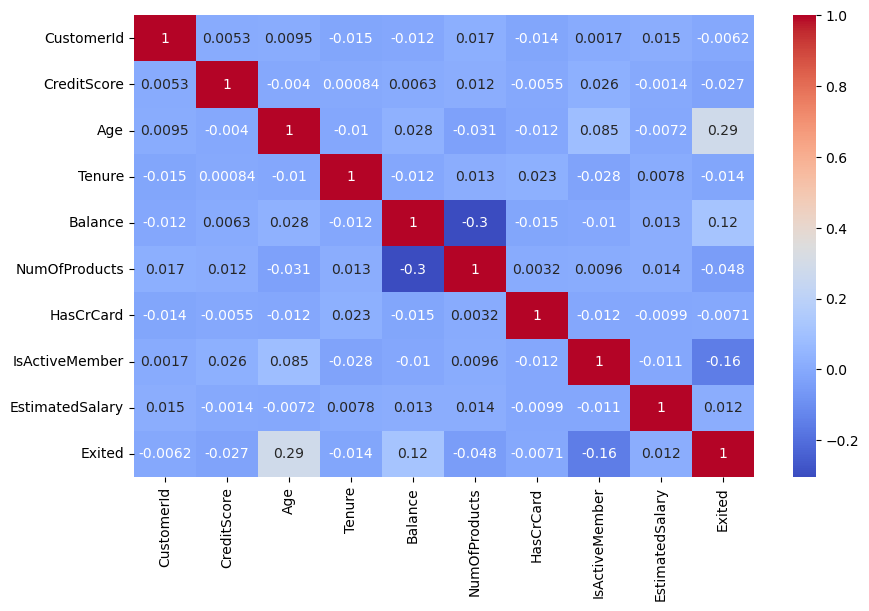

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.show()

In [96]:
grouped = df.groupby('Gender')['Exited'].agg(Count='value_counts')
grouped

Count
Gender Exited       
Female 0        3404
       1        1139
Male   0        4559
       1         898

In [97]:
df.drop(['CustomerId', 'Surname'], axis=1, inplace=True)

df = pd.get_dummies(df, drop_first=True)

In [98]:
# define x and y
X = df.drop('Exited', axis=1)
y = df['Exited']

In [99]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [100]:
results = []

In [101]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [102]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

results.append([
    "Logistic Regression",
    accuracy_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr),
    roc_auc_score(y_test, y_prob_lr)
])

In [103]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

results.append([
    "Decision Tree",
    accuracy_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt),
    roc_auc_score(y_test, y_prob_dt)
])

In [104]:
from sklearn.ensemble import RandomForestClassifier
rrf = RandomForestClassifier(random_state=42)
rrf.fit(X_train, y_train)

y_pred_rf = rrf.predict(X_test)
y_prob_rf = rrf.predict_proba(X_test)[:,1]

results.append([
    "Random Forest",
    accuracy_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf),
    roc_auc_score(y_test, y_prob_rf)
])

In [105]:
from sklearn.svm import SVC
svm = SVC(probability=True)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:,1]

results.append([
    "SVM",
    accuracy_score(y_test, y_pred_svm),
    recall_score(y_test, y_pred_svm),
    precision_score(y_test, y_pred_svm),
    f1_score(y_test, y_pred_svm),
    roc_auc_score(y_test, y_prob_svm)
])

In [106]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:,1]

results.append([
    "KNN",
    accuracy_score(y_test, y_pred_knn),
    recall_score(y_test, y_pred_knn),
    precision_score(y_test, y_pred_knn),
    f1_score(y_test, y_pred_knn),  # FIXED
    roc_auc_score(y_test, y_prob_knn)
])


In [107]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Recall", "Precision", "F1 Score", "ROC-AUC"
])

results_df

,Model,Accuracy,Recall,Precision,F1 Score,ROC-AUC
0,Logistic Regression,0.8110,0.201018,0.552448,0.294776,0.778900
1,Decision Tree,0.8575,0.396947,0.764706,0.522613,0.832790
2,Random Forest,0.8665,0.470738,0.758197,0.580848,0.864521
3,SVM,0.8560,0.381679,0.769231,0.510204,0.824739
4,KNN,0.8300,0.371501,0.610879,0.462025,0.760429


In [108]:
results_df.sort_values(by="Recall", ascending=False)

,Model,Accuracy,Recall,Precision,F1 Score,ROC-AUC
2,Random Forest,0.8665,0.470738,0.758197,0.580848,0.864521
1,Decision Tree,0.8575,0.396947,0.764706,0.522613,0.832790
3,SVM,0.8560,0.381679,0.769231,0.510204,0.824739
4,KNN,0.8300,0.371501,0.610879,0.462025,0.760429
0,Logistic Regression,0.8110,0.201018,0.552448,0.294776,0.778900


In [109]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=5,
    random_state=42
)

rf.fit(X,y)


RandomForestClassifier(max_depth=8, min_samples_split=5, n_estimators=200,
                       random_state=42)

In [110]:
y_prob = rf.predict_proba(X_test)[:,1]

threshold = 0.3  

y_pred = (y_prob > threshold).astype(int)
print("Recall:", recall_score(y_test, y_pred))

Recall: 0.6768447837150128


In [111]:
precision_score(y_test, y_pred)
f1_score(y_test, y_pred)

0.680306905370844

In [112]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1484  123]
 [ 127  266]]


In [113]:
import pickle

pickle.dump(dt, open("churn_model.pkl", "wb"))
pickle.dump(X.columns, open("model_columns.pkl", "wb"))

In [114]:
print(X.columns)

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='object')


In [115]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))

              Feature  Importance
1                 Age    0.362175
4       NumOfProducts    0.282868
6      IsActiveMember    0.084110
3             Balance    0.083585
8   Geography_Germany    0.054870
0         CreditScore    0.044489
7     EstimatedSalary    0.040635
2              Tenure    0.019706
10        Gender_Male    0.017831
9     Geography_Spain    0.005234
